In [ ]:
# The code below produces a plot of the Wilson Poisson flow as described in the paper:
# "Visualising the flows of orthogonal polynomial expansions of the Riemann Xi-function".
# The program reads the file with pre-computed coefficients and produces an implicit plot, 
# i.e. it visualises the flow of the real roots when r varies. 
# Version 1.0, December 29, 2025. 

In [204]:
%%gp
\\This code can be used to generate the first 150 coeficients of the expansion of the Wilsonflow for Xi(x) and a choice of a,b, a + b > 1 
default(realprecision, 120)
PH(y,z)=gamma(y+z) / gamma(y)
Phi(u) = 2*sum(n=1, 12, (2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
hyp4f3(n,k,a,b) = sum(j=0,k, (-1)^j*binomial(k,j)*PH(2*n+k+a+b-1/2,j)*PH(a+b+n,j) *PH(2*a+n,j) / (PH(2*n+2*a+2*b,j)*PH(n+a+1/2,j) * PH(n+a,j)))
Pochfac(n,k,a,b) = binomial(n+k,n)*PH(a+n,k)*PH(a+n+1/2,k)*PH(a+b+n,k) / PH(a+b+k+2*n-1/2,k)
Wil(n,x,a,b) = cosh(x/2)^(-2*a)*tanh(x/2)^(2*n)*sum(k=0,120, tanh(x/2)^(2*k)*2^(2*k) / gamma(2*n+2*k+1) * hyp4f3(n,k,a,b) * Pochfac(n,k,a,b) * hypergeom([a+n+k,a+n+k+1/2],[2*n+2*k+a+b+1/2],tanh(x/2)^2))
Wilcoeff(n,a,b) = 2^(2*n+1)/PH(n+2*a+2*b-1,n) * intnum(x=0,17, Phi(x) * Wil(n,x,a,b))

for(n=0,0, printf("%1.120e \n", Wilcoeff(n,34.03980893,34.03980893)))

Interrupting PARI/GP interpreter...


KeyboardInterrupt: Ctrl-c pressed while running PARI/GP interpreter

Automated checks:
The sum of all the coefficients is   : 67191576.5554627031087875 = Xi(ai) = 67191576.5554627031087875 (should be equal).
d/dr z_3(0) via Newton approximation : 3.045237 versus formula: -0.000004 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


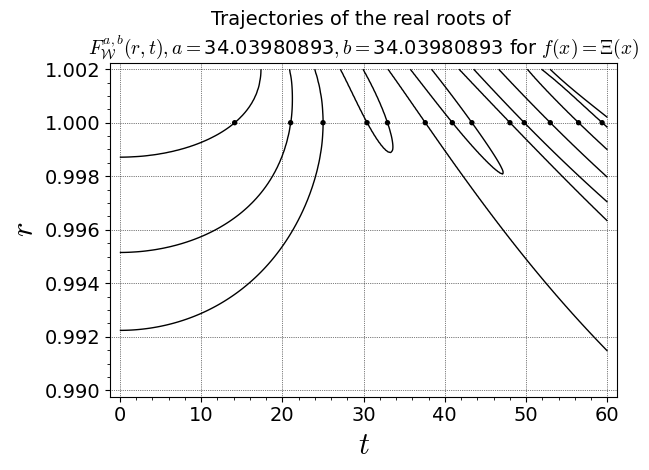

In [240]:
#Wilson flow of Xi_i for a, b. Using pre-computed coefficients

var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1524)
RDF=RealBallField(1524)

#Select the desired parameters a,b and c here
global a, b, N
N = 300

a = CCF("34.03980893")
b = CCF("34.03980893")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

global half
half = CCF("0.5")

global m1; m1 = []; CoeffSum = 0
n = 0
with open("WilsonCoeffa34d03980893b34d03980893New.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + PH(a + b, n).pow(2) * PH(2 * a, n) * RDF(row)
        m1.append([RDF(row)])
        n = n + 1

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def WilsonPoly(t, n):
    pre = PH(a + b, n).pow(2) * PH(2 * a, n)
    f1  =  CCF(a,0) + I*CCF(t); f2 = CCF(a,0) - I*CCF(t)
    Wilpol = pre * CCF(1).hypergeometric([-n, n + 2 * a + 2 * b - 1, f1, f2],[a + b, 2 * a, a + b])
    return Wilpol

def WilsonFlow(t,rho):
    sum=CCF(0)
    for n in range(N):
        kappa = CCF(n + 2 * a + 2 * b - 1) 
        g = CCF(rho)
        sum=sum + g.pow(n*kappa)*CCF(str(m1[n]))*WilsonPoly(t, n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(WilsonFlow(x0 + tr*100,1+tr) - WilsonFlow(x0,1+tr))/(tr*100)
        h =RDF(WilsonFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)*(a.mid()-I*x)*(b.mid()-I*x)/(2*I*x*(2*I*x-1))

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)*(a.mid()+I*x)*(b.mid()+I*x)/(2*I*x*(2*I*x+1))

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1])*prodzeros(k,I) + D(ordrho[k-1])*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), WilsonFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,1)-Xi(60).mid()))

a1=implicit_plot(lambda t,r:RDF(WilsonFlow(t,r)),(t,0,60),(r,0.99,1.002),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{W}}(r,t), a=$' + astr + r'$, b=$'+ bstr + ' for $f(x)=\Xi(x)$',gridlines=True,plot_points=210)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 0.6942731926050385 = Xi(ai) = 0.6942731926050385 (should be equal).
d/dr z_3(0) via Newton approximation : -0.403341 versus formula: -0.011343 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


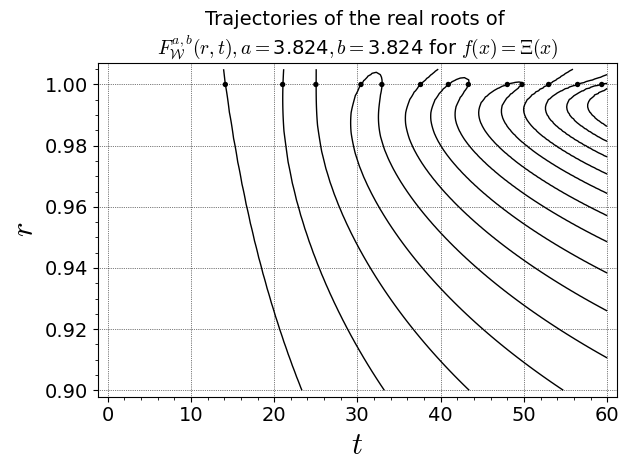

In [249]:
#Wilson flow of Xi_i for a, b. Using pre-computed coefficients

var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1524)
RDF=RealBallField(1524)

#Select the desired parameters a,b and c here
global a, b, N
N = 200

a = CCF("3.824")
b = CCF("3.824")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

global half
half = CCF("0.5")

global m1; m1 = []; CoeffSum = 0
n = 0
with open("WilsonCoeffa3d824b3d824New.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + PH(a + b, n).pow(2) * PH(2 * a, n) * RDF(row)
        m1.append([RDF(row)])
        n = n + 1

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def WilsonPoly(t, n):
    pre = PH(a + b, n).pow(2) * PH(2 * a, n)
    f1  =  CCF(a,0) + I*CCF(t); f2 = CCF(a,0) - I*CCF(t)
    Wilpol = pre * CCF(1).hypergeometric([-n, n + 2 * a + 2 * b - 1, f1, f2],[a + b, 2 * a, a + b])
    return Wilpol

def WilsonFlow(t,rho):
    sum=CCF(0)
    for n in range(N):
        kappa = CCF(n + 2 * a + 2 * b - 1) 
        g = CCF(rho)
        sum=sum + g.pow(n*kappa)*CCF(str(m1[n]))*WilsonPoly(t, n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(WilsonFlow(x0 + tr*100,1+tr) - WilsonFlow(x0,1+tr))/(tr*100)
        h =RDF(WilsonFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)*(a.mid()-I*x)*(b.mid()-I*x)/(2*I*x*(2*I*x-1))

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)*(a.mid()+I*x)*(b.mid()+I*x)/(2*I*x*(2*I*x+1))

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1])*prodzeros(k,I) + D(ordrho[k-1])*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), WilsonFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,1)-Xi(60).mid()))

a1=implicit_plot(lambda t,r:RDF(WilsonFlow(t,r)),(t,0,60),(r,0.9,1.005),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{W}}(r,t), a=$' + astr + r'$, b=$'+ bstr + ' for $f(x)=\Xi(x)$',gridlines=True,plot_points=120)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 1.0058696833082144 = Xin(ai) = 1.0058696833082144 (should be equal).
d/dr z_3(0) via Newton approximation : 0.008399 versus formula: 0.008399 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


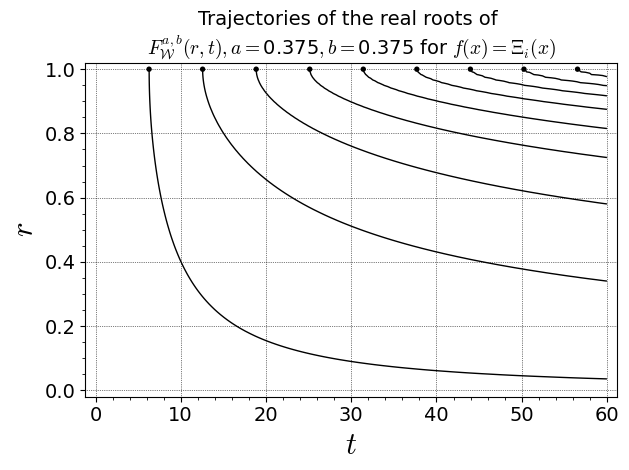

In [241]:
#Wilson flow of Xi_i for a, b.
var("r", "t", "y");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Select the desired parameters a,b and c here
global a, b, N
N = 250

a = CCF("0.375")
b = CCF("0.375")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

global half
half = CCF("0.5")

global m1; m1 = []; CoeffSum = 0
n = 0
with open("WilsonCoeffa0d375b0d375IntNew.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + PH(a + b, n).pow(2) * PH(2 * a, n) * RDF(row)
        m1.append([RDF(row)])
        n = n + 1

# Make the plot based on the coefficients for a and b

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def WilsonPoly(t, n):
    pre = PH(a + b, n).pow(2) * PH(2 * a, n)
    f1  =  CCF(a,0) + I*CCF(t); f2 = CCF(a,0) - I*CCF(t)
    Wilpol = pre * CCF(1).hypergeometric([-n, n + 2 * a + 2 * b - 1, f1, f2],[a + b, 2 * a, a + b])
    return Wilpol

def WilsonFlow(t,rho):
    sum=CCF(0)
    for n in range(N):
        kappa = CCF(n + 2 * a + 2 * b - 1)
        g = CCF(rho)
        sum=sum + g.pow(n*kappa)*CCF(str(m1[n]))*WilsonPoly(t, n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(WilsonFlow(x0 + tr*100,1+tr) - WilsonFlow(x0,1+tr)) / (tr*100)
        h = RDF(WilsonFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)*(a.mid()-I*x)*(b.mid()-I*x)/(2*I*x*(2*I*x-1))

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)*(a.mid()+I*x)*(b.mid()+I*x)/(2*I*x*(2*I*x+1))

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk = 2*pi()*k
    return 2*zk*sin(c/2)/(zk +c)    

#compute d/dr zk via formula
def verifyDDE(k):
    return B(2 * pi() * k)*ZS(k,I) + D(2 * pi() * k)*ZS(k,-I)
    
print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xin(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), WilsonFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),real_part((verifyDDE(3)))))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,1)-Xin(60).mid()))

a1i=implicit_plot(lambda t,r:RDF(WilsonFlow(t,r)),(t,0,60),(r,0,1),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{W}}(r,t), a=$' + astr + r'$, b=$'+ bstr + ' for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=120)
show(a1i + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 925.8908915440496230 = Xin(ai) = 925.8908915440496230 (should be equal).
d/dr z_3(0) via Newton approximation : 0.027272 versus formula: 0.027272 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


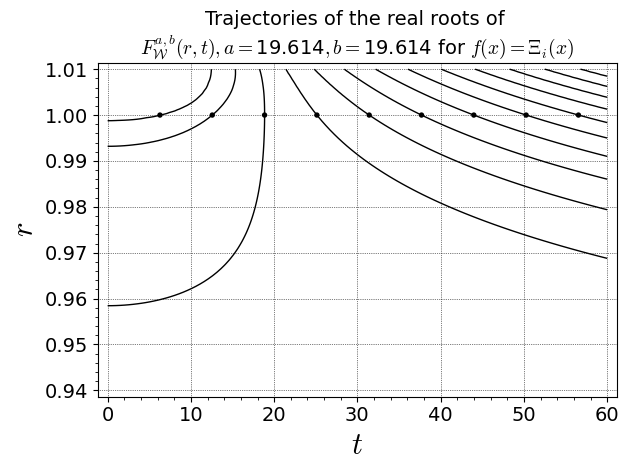

In [250]:
#Wilson flow of Xi_i for a, b.
var("r", "t", "y");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Select the desired parameters a,b and c here
global a, b, N
N = 150

a = CCF("19.614")
b = CCF("19.614")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

global half
half = CCF("0.5")

global m1; m1 = []; CoeffSum = 0
n = 0
with open("WilsonCoeffa19d614b19d614IntNew.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + PH(a + b, n).pow(2) * PH(2 * a, n) * RDF(row)
        m1.append([RDF(row)])
        n = n + 1

# Make the plot based on the coefficients for a and b

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def WilsonPoly(t, n):
    pre = PH(a + b, n).pow(2) * PH(2 * a, n)
    f1  =  CCF(a,0) + I*CCF(t); f2 = CCF(a,0) - I*CCF(t)
    Wilpol = pre * CCF(1).hypergeometric([-n, n + 2 * a + 2 * b - 1, f1, f2],[a + b, 2 * a, a + b])
    return Wilpol

def WilsonFlow(t,rho):
    sum=CCF(0)
    for n in range(N):
        kappa = CCF(n + 2 * a + 2 * b - 1)
        g = CCF(rho)
        sum=sum + g.pow(n*kappa)*CCF(str(m1[n]))*WilsonPoly(t, n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(WilsonFlow(x0 + tr*100,1+tr) - WilsonFlow(x0,1+tr)) / (tr*100)
        h = RDF(WilsonFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)*(a.mid()-I*x)*(b.mid()-I*x)/(2*I*x*(2*I*x-1))

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)*(a.mid()+I*x)*(b.mid()+I*x)/(2*I*x*(2*I*x+1))

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk = 2*pi()*k
    return 2*zk*sin(c/2)/(zk +c)    

#compute d/dr zk via formula
def verifyDDE(k):
    return B(2 * pi() * k)*ZS(k,I) + D(2 * pi() * k)*ZS(k,-I)
    
print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xin(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), WilsonFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),real_part((verifyDDE(3)))))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,1)-Xin(60).mid()))

a1i=implicit_plot(lambda t,r:RDF(WilsonFlow(t,r)),(t,0,60),(r,0.94,1.01),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{W}}(r,t), a=$' + astr + r'$, b=$'+ bstr + ' for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=120)
show(a1i + z,aspect_ratio='automatic')

The sum of all the coefficients is : 0.5000000000000000 = Xi(a*i) 

Automated checks:
The sum of all the coefficients is   : 0.5000000000000000 = Xi(0.5i) = 0.5000000000000000 (should be equal).
d/dr z_3(0) via Newton approximation : -171.015975 versus formula: -170.688524 (should be close).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


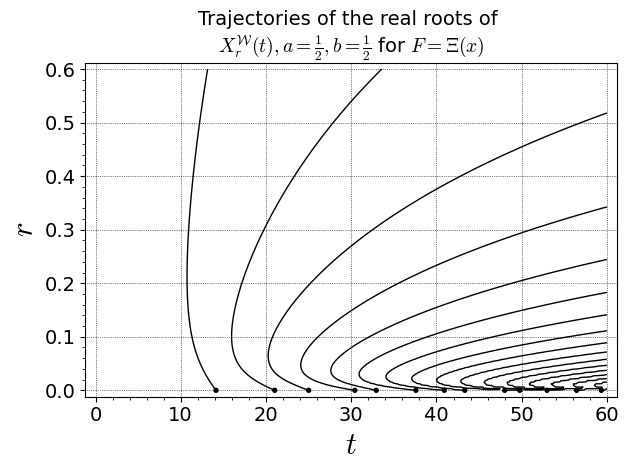

In [1]:
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,0])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

RDF=RealBallField(1024)
global m1; m1 = []; CoeffSum = 0
with open("WilsonCoeffa12b12c12d12", "r") as f:
    for row in f:
        CoeffSum= CoeffSum + RDF(row)
        m1.append([RDF(row)])
print("The sum of all the coefficients is : %3.16f = Xi(a*i) \n" % CoeffSum)

CCF=ComplexBallField(1024)
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def hyp(t,a,b,c,d,n):
    f1=CCF(a,0)+I*CCF(t);f2=CCF(a,0)-I*CCF(t)
    hp=CCF(1).hypergeometric([-n,n+a+b+c+d-1,f1,f2],[a+b,a+c,a+d])
    return hp

def WilsonFlow(t,r):
    sum=CCF(0)
    for n in range(150):
        h = n+CCF("1")
        r1 = CCF(-r,0).exp()
        g = r1.pow(h)
        sum=sum+g.pow(n)*CCF(str(m1[n]))*hyp(t,CCF("0.5"),CCF("0.5"),CCF("0.5"),CCF("0.5"),n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (WilsonFlow(x0 + tr*100,tr) - WilsonFlow(x0,tr))/(tr*100)
        h = WilsonFlow(x0,tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = (x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

def B(x,a,b,c,d):
    return (a-I*x)*(b-I*x)*(c-I*x)*(d-I*x)/(2*I*x*(2*I*x-1))

def D(x,a,b,c,d):
    return (a+I*x)*(b+I*x)*(c+I*x)*(d+I*x)/(2*I*x*(2*I*x+1))

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1],0.5,0.5,0.5,0.5)*prodzeros(k,I) + D(ordrho[k-1],0.5,0.5,0.5,0.5)*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(0.5i) = %3.16f (should be equal)." % (CoeffSum, WilsonFlow(0.5*I,0)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,0)-Xi(60)))

a1=implicit_plot(lambda t,r:((RDF(WilsonFlow(t,r)))),(t,0,60),(r,0,0.6),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' + r'$X^{\mathcal{W}}_r(t), a=\frac{1}{2}, b=\frac{1}{2}$ for $F=\Xi(x)$',gridlines=True,plot_points=200)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 67191575.0284538269042969 = Xi(34.03980i) = 67191575.0284538120031357 (should be equal).
d/dr z_3(0) via Newton approximation : 3.045180 versus formula: -0.000000 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


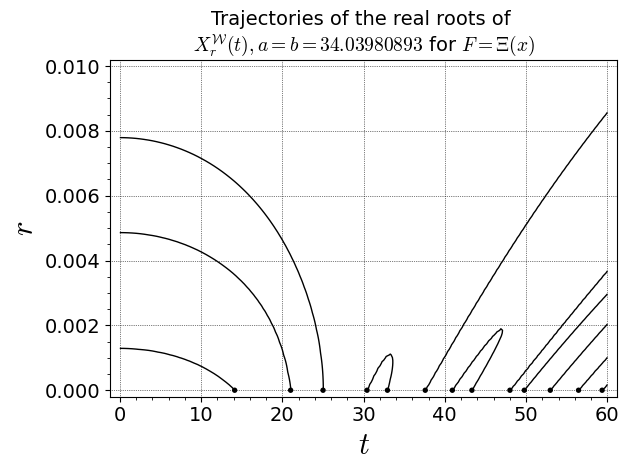

In [2]:
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,0])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

RDF=RealBallField(1024)
global m1; m1 = []; CoeffSum = 0
with open("WilsonCoeffaaaa34", "r") as f:
    for row in f:
        CoeffSum= CoeffSum + RDF(row)
        m1.append([RDF(row)])

CCF=ComplexBallField(1024)
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def hyp(t,a,b,c,d,n):
    f1=CCF(a,0)+I*CCF(t);f2=CCF(a,0)-I*CCF(t)
    hp=CCF(1).hypergeometric([-n,n+a+b+c+d-1,f1,f2],[a+b,a+c,a+d])
    return hp

def WilsonFlow(t,r):
    sum=CCF(0)
    for n in range(106):
        h = n+4*CCF("34.039808904643568083")-CCF("1")
        r1 = CCF(-r,0).exp()
        g = r1.pow(h)
        sum=sum+g.pow(n)*CCF(str(m1[n]))*hyp(t,CCF("34.039808904643568083"),CCF("34.039808904643568083"),CCF("34.039808904643568083"),CCF("34.039808904643568083"),n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (WilsonFlow(x0 + tr*100,tr) - WilsonFlow(x0,tr))/(tr*100)
        h = WilsonFlow(x0,tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = (x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

def B(x,a,b,c,d):
    return (a-I*x)*(b-I*x)*(c-I*x)*(d-I*x)/(2*I*x*(2*I*x-1))

def D(x,a,b,c,d):
    return (a+I*x)*(b+I*x)*(c+I*x)*(d+I*x)/(2*I*x*(2*I*x+1))

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1],34.039808904643568083,34.039808904643568083,34.039808904643568083,34.039808904643568083)*prodzeros(k,I) + D(ordrho[k-1],34.039808904643568083,34.039808904643568083,34.039808904643568083,34.039808904643568083)*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(34.03980i) = %3.16f (should be equal)." % (CoeffSum, WilsonFlow(34.039808904643568083*I,0)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,0)-Xi(60)))
a1=implicit_plot(lambda t,r:((RDF(WilsonFlow(t,r)))),(t,0,60),(r,0,0.01),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' + r'$X^{\mathcal{W}}_r(t), a=b=34.03980893$ for $F=\Xi(x)$',gridlines=True,plot_points=120)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 0.6942977055291927 = Xi(3.824204350568i) = 0.6942977055291927 (should be equal).
d/dr z_3(0) via Newton approximation : -0.392012 versus formula: 0.000000 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


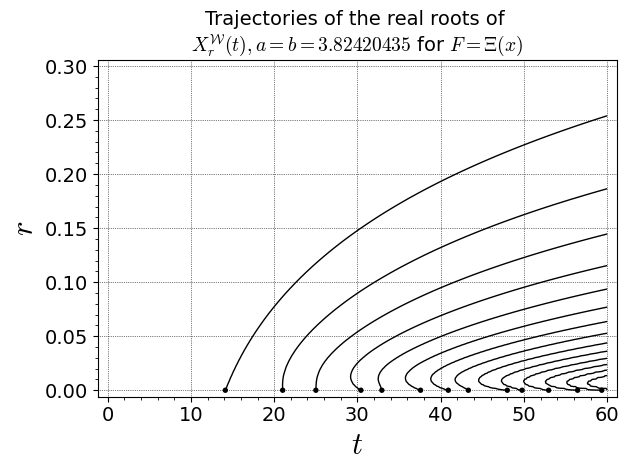

In [3]:
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,0])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

RDF=RealBallField(1024)
global m1; m1 = []; CoeffSum = 0
with open("WilsonCoeffaaaa3d8", "r") as f:
    for row in f:
        CoeffSum= CoeffSum + RDF(row)
        m1.append([RDF(row)])

CCF=ComplexBallField(1024)
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def hyp(t,a,b,c,d,n):
    f1=CCF(a,0)+I*CCF(t);f2=CCF(a,0)-I*CCF(t)
    hp=CCF(1).hypergeometric([-n,n+a+b+c+d-1,f1,f2],[a+b,a+c,a+d])
    return hp

def WilsonFlow(t,r):
    sum=CCF(0)
    for n in range(130):
        h = n+4*CCF("3.8242043505682231856")-CCF("1")
        r1 = CCF(-r,0).exp()
        g = r1.pow(h)
        sum=sum+g.pow(n)*CCF(str(m1[n]))*hyp(t,CCF("3.8242043505682231856"),CCF("3.8242043505682231856"),CCF("3.8242043505682231856"),CCF("3.8242043505682231856"),n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (WilsonFlow(x0 + tr*100,tr) - WilsonFlow(x0,tr))/(tr*100)
        h = WilsonFlow(x0,tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = (x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

def B(x,a,b,c,d):
    return (a-I*x)*(b-I*x)*(c-I*x)*(d-I*x)/(2*I*x*(2*I*x-1))

def D(x,a,b,c,d):
    return (a+I*x)*(b+I*x)*(c+I*x)*(d+I*x)/(2*I*x*(2*I*x+1))

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1],3.8242043505682231856,3.8242043505682231856,3.8242043505682231856,3.8242043505682231856)*prodzeros(k,I) + D(ordrho[k-1],3.8242043505682231856,3.8242043505682231856,3.8242043505682231856,3.8242043505682231856)*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(3.824204350568i) = %3.16f (should be equal)." % (CoeffSum, WilsonFlow(3.8242043505682231856*I,0)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,0)-Xi(60)))
a1=implicit_plot(lambda t,r:((RDF(WilsonFlow(t,r)))),(t,0,60),(r,0,0.3),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' + r'$X^{\mathcal{W}}_r(t), a=b=3.82420435$ for $F=\Xi(x)$',gridlines=True,plot_points=180)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 1.0104492672326733 = Xin(0.5i) = 1.0104492672326733 (should be equal).
d/dr z_3(0) via Newton approximation : 4.914653 versus formula: 4.914653 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


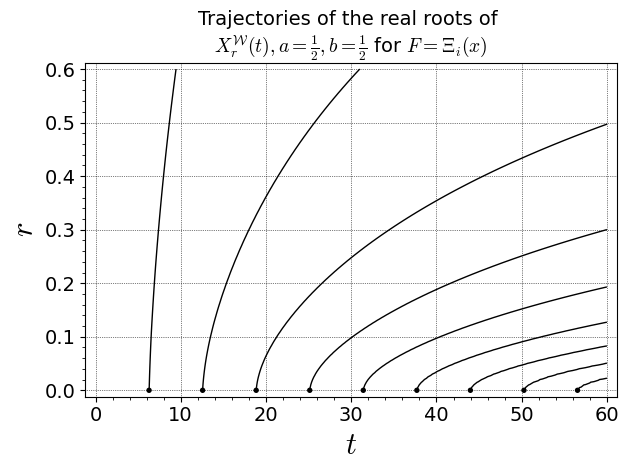

In [4]:
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),0])
z1=list_plot(ord, size=15, marker="o", color = "black")

RDF=RealBallField(1024)
global m1; m1 = []; CoeffSum = 0
with open("WilsonCoeffa12b12c12d12int", "r") as f:
    for row in f:
        CoeffSum= CoeffSum + RDF(row)
        m1.append([RDF(row)])

CCF=ComplexBallField(1024)
def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def hyp(t,a,b,c,d,n):
    f1=CCF(a,0)+I*CCF(t);f2=CCF(a,0)-I*CCF(t)
    hp=CCF(1).hypergeometric([-n,n+a+b+c+d-1,f1,f2],[a+b,a+c,a+d])
    return hp

def WilsonFlow(t,r):
    sum=CCF(0)
    for n in range(150):
        h = n+CCF("1")
        r1 = CCF(-r,0).exp()
        g = r1.pow(h)
        sum=sum+g.pow(n)*CCF(str(m1[n]))*hyp(t,CCF("0.5"),CCF("0.5"),CCF("0.5"),CCF("0.5"),n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000000001");x0 = RDF(2*k*pi());
    while(y):
        hd = (WilsonFlow(x0 + tr*100,tr) - WilsonFlow(x0,tr))/(tr*100)
        h = WilsonFlow(x0,tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = (x1 - RDF(2*pi()*k))/(tr) 
    return dzdr3

def B(x,a,b,c,d):
    return (a-I*x)*(b-I*x)*(c-I*x)*(d-I*x)/(2*I*x*(2*I*x-1))

def D(x,a,b,c,d):
    return (a+I*x)*(b+I*x)*(c+I*x)*(d+I*x)/(2*I*x*(2*I*x+1))

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk =2*pi()*k
    return (-1)^k*zk*c^4*sin(pi()*k+c/2)/(pi()*k+c/2)     

#compute d/dr zk via formula
def verifyDDE(k):
    return B(2*pi()*k,0.5,0.5,0.5,0.5)*ZS(k,I) +D(2*pi()*k,0.5,0.5,0.5,0.5)*ZS(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xin(0.5i) = %3.16f (should be equal)." % (CoeffSum, WilsonFlow(0.5*I,0)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),real_part(verifyDDE(3))))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,0)-Xin(60)))

a1i=implicit_plot(lambda t,r:((RDF(WilsonFlow(t,r)))),(t,0,60),(r,0,0.6),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' + r'$X^{\mathcal{W}}_r(t), a=\frac{1}{2}, b=\frac{1}{2}$ for $F=\Xi_i(x)$',gridlines=True,plot_points=120)
show(a1i + z1,aspect_ratio='automatic')

In [63]:
#Generate coefficients for Wilson for flow of Xi_i for a, b.
var("r", "t", "y");

CCF=ComplexBallField(801)
RDF=RealBallField(801)

#Select the desired parametes a and b here
global a, b
a = CCF("1")
b = CCF("1")

global half
half = CCF("0.5")

# Generate and store the coefficients for the choice of a, b, c

def PH(z, n):
    return (z + n).gamma() / (z).gamma()

def hyp2F1(a1, a2, b1, y):
    return  CCF(y).hypergeometric([a1, a2],[b1])

def C(n, kr):
    pterm = PH(n + a, kr) * PH(n + a + half, kr) * PH(n + a + b, kr) * PH(a + b + 2 * n - half, kr) / ((kr + 1).gamma() * PH(n + half, kr) * PH(a + b + 2 * n - half, 2 * kr))
    return  pterm * CCF(1).hypergeometric([-kr, 2*n + kr + a + b - half, n + a + b, n + 2 * a] ,[2 * n + 2 * a + 2 * b, n + a + half, n + a])

def ksum(n, x):
    ksum=(RDF(0))
    for k in range(60):
        kr = RDF(k)
        ksummand =  C(n, kr) * x.pow(2 * kr) * hyp2F1(a + n + kr, a + n + kr + half, 2 * n + 2 * kr + a + b + half, x.pow(2))
        ksum = ksum + ksummand
    return ksum

def integrand(n, x):
    integr = x.pow(2 * n) * (1 - x.pow(2)).pow(a - 1) * ksum(n, x)
    return integr 

def Wilcoeff(n):
    pre = CCF(2).pow(2 * n + 2) / (CCF(2 * n + 1).gamma() * PH(n + 2 * a + 2 * b - 1,n))
    res =  pre * CCF.integral(lambda y, _: integrand(n, y), CCF("0"), CCF("0.25").tanh())
    return real_part(res)

print("Computing 200 coefficients...")

global m1; m1 = [];
for n in range(150):
    Coe = Wilcoeff(n)
    print(Coe)
    m1.append([Coe]) 

print("Done!")

Computing 200 coefficients...
[0.9592555423240447019759901566649312506876795085109349915817428932172219887078595161106532408868749319492668235080446143966623104575453256810517476801340243317205776207263507798197459068229085758285201833693108560284722912118632676636998877 +/- 2.82e-239]
[0.009909834252001982188019100350387207464464774401999267955797689561014775872044213032166987501723407087797249103205566775551174121948831911462143240337355081072307216034099144241414970108927470913199043788379785182204776530041965960955324007 +/- 7.75e-241]
[1.6360542288532839150945503593695159991969977278474542783334095117072889325466003407551684870273674893445382509219739237866468176870406841590606752508586460080345738544732562096580329097238514406019843226854477100561754039971012079384601501e-5 +/- 8.71e-244]
[8.60953185186890595415449720242824136280167167432918710784393119520091823080537296893815811334382729535243079844289198023406686783241250072847379709274536758058507625889632607705631305321169472

In [ ]:
#Wilson flow of Xi_i for a, b.
var("r", "t", "y");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),0])
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Select the desired parameters a,b and c here
global a, b, N
N = 200

a = CCF("1.1")
b = CCF("2.1")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

global half
half = CCF("0.5")

# Generate and store the coefficients for the choice of a, b, c

def PH(z, n):
    return (z + n).gamma() / (z).gamma()

def hyp2F1(a1, a2, b1, y):
    return  CCF(y).hypergeometric([a1, a2],[b1])

def C(n, kr):
    pterm = PH(n + a, kr) * PH(n + a + half, kr) * PH(n + a + b, kr) * PH(a + b + 2 * n - half, kr) / ((kr + 1).gamma() * PH(n + half, kr) * PH(a + b + 2 * n - half, 2 * kr))
    return  pterm * CCF(1).hypergeometric([-kr, 2*n + kr + a + b - half, n + a + b, n + 2 * a] ,[2 * n + 2 * a + 2 * b, n + a + half, n + a])

def ksum(n, x):
    ksum=(RDF(0))
    for k in range(60):
        kr = RDF(k)
        ksummand =  C(n, kr) * x.pow(2 * kr) * hyp2F1(a + n + kr, a + n + kr + half, 2 * n + 2 * kr + a + b + half, x.pow(2))
        ksum = ksum + ksummand
    return ksum

def integrand(n, x):
    integr = x.pow(2 * n) * (1 - x.pow(2)).pow(a - 1) * ksum(n, x)
    return integr 

def Wilcoeff(n):
    pre = CCF(2).pow(2 * n + 2) / (CCF(2 * n + 1).gamma() * PH(n + 2 * a + 2 * b - 1,n))
    res =  pre * CCF.integral(lambda y, _: integrand(n, y), CCF("0"), CCF("0.25").tanh())
    return real_part(res)

print("Computing 200 coefficients...")

global m1; m1 = [];
CoeffSum = CCF("0")
for n in range(N + 1):
    Coe = Wilcoeff(n)
    CoeffSum = CoeffSum + PH(a + b, n).pow(2) * PH(2 * a, n) * Coe
    m1.append([Coe]) 

print("Done!")
print("Preparing plot...")

# Make the plot based on the coefficients for a and b

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def WilsonPoly(t, n):
    pre = PH(a + b, n).pow(2) * PH(2 * a, n)
    f1  =  CCF(a,0) + I*CCF(t); f2 = CCF(a,0) - I*CCF(t)
    Wilpol = pre * CCF(1).hypergeometric([-n, n + 2 * a + 2 * b - 1, f1, f2],[a + b, 2 * a, a + b])
    return Wilpol

def WilsonFlow(t,rho):
    sum=CCF(0)
    for n in range(N):
        kaprho = CCF(n + 2 * a + 2 * b - 1) * CCF(rho)
        g = CCF(-kaprho).exp()
        sum=sum + g.pow(n)*CCF(str(m1[n]))*WilsonPoly(t, n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(WilsonFlow(x0 + tr*100,tr) - WilsonFlow(x0,tr)) / (tr*100)
        h = RDF(WilsonFlow(x0,tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = (x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)*(a.mid()-I*x)*(b.mid()-I*x)/(2*I*x*(2*I*x-1))

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)*(a.mid()+I*x)*(b.mid()+I*x)/(2*I*x*(2*I*x+1))

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk = 2*pi()*k
    return 2*zk*sin(c/2)/(zk +c)    

#compute d/dr zk via formula
def verifyDDE(k):
    return B(2 * pi() * k)*ZS(k,I) + D(2 * pi() * k)*ZS(k,-I)
    
print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xin(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), WilsonFlow(CCF(0,a),0)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyDDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(WilsonFlow(60,0)-Xin(60).mid()))

a1i=implicit_plot(lambda t,r:RDF(WilsonFlow(t,r)),(t,0,60),(r,-0.5,1),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$\rho$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{W}}(\rho,t), a=$' + astr + r'$, b=$'+ bstr + ' for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=90)
show(a1i + z,aspect_ratio='automatic')

In [177]:
#Generate coefficients for Wilson for flow of Xi_i for a, b.
var("r", "t", "y");

CCF=ComplexBallField(801)
RDF=RealBallField(801)

#Select the desired parametes a and b here
global a, b
a = CCF("1")
b = CCF("1")

global half
half = CCF("0.5")

# Generate and store the coefficients for the choice of a, b, c

def PH(z, n):
    return (z + n).gamma() / (z).gamma()

def hyp2F1(a1, a2, b1, y):
    return  CCF(y).hypergeometric([a1, a2],[b1])

def C(n, kr):
    pterm = CCF(2).pow(2*kr)*PH(n + a, kr) * PH(n + a + half, kr) * PH(n + a + b, kr) * gamma(n + kr + 1).gamma() / ((kr + 1).gamma() * (n + 1).gamma() * PH(a + b + kr + 2 * n - half, kr)*gamma(2*n+2*kr+1))
    return  pterm * CCF(1).hypergeometric([-kr, 2*n + kr + a + b - half, n + a + b, n + 2 * a] ,[2 * n + 2 * a + 2 * b, n + a + half, n + a])

def integrand(n, kr, x):
    integr = x.pow(2 * (n+kr)) * (1 - x.pow(2)).pow(a - 1) * hyp2F1(a + n + kr, a + n + kr + half, 2 * n + 2 * kr + a + b + half, x.pow(2))
    return integr 

def ksum(n):
    ksum=(RDF(0))
    for k in range(60):
        kr = RDF(k)
        ksummand =  C(n, kr) * *CCF.integral(lambda y, _: integrand(n, kr, y), CCF("0"), CCF("0.25").tanh())
        ksum = ksum + ksummand
    return ksum

def Wilcoeff(n):
    pre = CCF(2).pow(2 * n + 2) / PH(n + 2 * a + 2 * b - 1,n)
    res =  pre * ksum(n)
    return real_part(res)

print("Computing 150 coefficients...")

global m1; m1 = [];
for n in range(150):
    Coe = Wilcoeff(n)
    print(Coe)
    m1.append([Coe]) 

print("Done!")

Computing 150 coefficients...
[0.9592555423240447019759901566649312506876795085109349915817428932172219887078595161106532408868749319492668235080446143966623104575453256810517476801340243317205776207263507798197459068229085758285201833693108560284722912118632676636998877 +/- 2.97e-239]
[0.009909834252001982188019100350387207464464774401999267955797689561014775872044213032166987501723407087797249103205566775551174121948831911462143240337355081072307216034099144241414970108927470913199043788379785182204776530041965960955324007 +/- 7.74e-241]
[1.6360542288532839150945503593695159991969977278474542783334095117072889325466003407551684870273674893445382509219739237866468176870406841590606752508586460080345738544732562096580329097238514406019843226854477100561754039971012079384601501e-5 +/- 9.01e-244]
[8.60953185186890595415449720242824136280167167432918710784393119520091823080537296893815811334382729535243079844289198023406686783241250072847379709274536758058507625889632607705631305321169472

In [ ]:
# Generate and store the coefficients for the choice of a, b, c

def PH(z, n):
    return (z + n).gamma() / (z).gamma()

def hyp2F1(a1, a2, b1, y):
    return  CCF(y).hypergeometric([a1, a2],[b1])

def C(n, kr):
    pterm = PH(n + a, kr) * PH(n + a + half, kr) * PH(n + a + b, kr) * PH(a + b + 2 * n - half, kr) / ((kr + 1).gamma() * PH(n + half, kr) * PH(a + b + 2 * n - half, 2 * kr))
    return  pterm * CCF(1).hypergeometric([-kr, 2*n + kr + a + b - half, n + a + b, n + 2 * a] ,[2 * n + 2 * a + 2 * b, n + a + half, n + a])

def ksum(n, x):
    ksum=(RDF(0))
    for k in range(60):
        kr = RDF(k)
        ksummand =  C(n, kr) * x.pow(2 * kr) * hyp2F1(a + n + kr, a + n + kr + half, 2 * n + 2 * kr + a + b + half, x.pow(2))
        ksum = ksum + ksummand
    return ksum

def integrand(n, x):
    integr = x.pow(2 * n) * (1 - x.pow(2)).pow(a - 1) * ksum(n, x)
    return integr 

def Wilcoeff(n):
    pre = CCF(2).pow(2 * n + 2) / (CCF(2 * n + 1).gamma() * PH(n + 2 * a + 2 * b - 1,n))
    res =  pre * CCF.integral(lambda y, _: integrand(n, y), CCF("0"), CCF("0.25").tanh())
    return real_part(res)

print("Computing 150 coefficients...")

global m1; m1 = [];
CoeffSum = CCF("0")
for n in range(N + 1):
    Coe = Wilcoeff(n)
    print(Coe)
    CoeffSum = CoeffSum + PH(a + b, n).pow(2) * PH(2 * a, n) * Coe
    m1.append([Coe]) 

print("Done!")
print("Preparing plot...")